## Analysis 1 - Revenue and growth Trend

**Business question** Is this business growing and is there a measurable seasonality in purchase behavior?

### Final findings 
This analysis evaluates monthly revenue trends using 20 complete months of data from the Olist marketplace (January 2017 to August 2018), excluding partial months to avoid distortion.

Revenue shows *strong upward growth*, increasing from **R$9.27M in 2017 to R$11.13M** in the first eight months of 2018 (+20.1%). While annualising 2018 suggests substantially higher growth, this projection assumes stable revenue across the remaining months , an assumption that may not hold given observed volatility and seasonality.

A pronounced revenue spike occurs in **November 2017 (R$1.6M, +55% MoM)**, consistent with Black Friday effects, followed by a **sharp contraction in December (-34%)**, indicating post-promotion demand pull-forward rather than sustained growth.

Contrary to typical Northern Hemisphere retail patterns, peak revenue months are concentrated mid-year (May–August). However, interpretation is constrained by incomplete late-2018 data, limiting direct month-to-month comparability.

Growth dynamics shift over time: early 2017 exhibits hypergrowth **(up to +85% MoM)**, while 2018 stabilises to low single-digit growth, suggesting a transition from rapid expansion to a more mature revenue phase.

Overall, the platform demonstrates strong growth with emerging signs of maturation, event-driven revenue spikes, and locally specific seasonal patterns.




In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
master = pd.read_csv('../data/processed/master.csv',
                     parse_dates=['order_purchase_timestamp',
                                   'order_delivered_customer_date', 'order_estimated_delivery_date', ])
rfm_base = pd.read_csv('../data/processed/rfm_base.csv')

COLOUR_PRIMARY = '#14213d'
COLOUR_ACCENT =  '#415a77'
COLOUR_HIGHLIGHT = '#fb5607'
COLOUR_EMPHASIS = '#d00000'

In [2]:
master.shape


(113425, 29)

In [3]:
rfm_base.shape

(96136, 10)

In [4]:
master.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'product_id', 'seller_id', 'price', 'freight_value', 'review_score',
       'review_comment_message', 'product_category_name_english',
       'customer_unique_id', 'customer_city', 'customer_state',
       'payment_value', 'payment_type', 'payment_installments',
       'payment_count', 'seller_state', 'order_month', 'order_yeah',
       'order_dayofweek', 'delivery_delay_days', 'total_item_value',
       'was_late'],
      dtype='str')

In [5]:
[col for col in master.columns if 'payment' in col.lower()]

['payment_value', 'payment_type', 'payment_installments', 'payment_count']

In [6]:
print(master['order_month'])

0         2017-10
1         2018-07
2         2018-08
3         2017-11
4         2018-02
           ...   
113420    2018-02
113421    2017-08
113422    2018-01
113423    2018-01
113424    2018-03
Name: order_month, Length: 113425, dtype: str


In [7]:
#trying to find out which months have 27+ days
days_per_month = (
    master
    .groupby('order_month')['order_purchase_timestamp']
    .apply(lambda x: x.dt.day.nunique())
    .reset_index()
    .rename(columns={'order_purchase_timestamp' : 'days_with_orders'})

)

print(days_per_month.to_string(index=False))

order_month  days_with_orders
    2016-09                 4
    2016-10                10
    2016-12                 1
    2017-01                27
    2017-02                28
    2017-03                31
    2017-04                30
    2017-05                31
    2017-06                30
    2017-07                31
    2017-08                31
    2017-09                30
    2017-10                31
    2017-11                30
    2017-12                31
    2018-01                31
    2018-02                28
    2018-03                31
    2018-04                30
    2018-05                31
    2018-06                30
    2018-07                31
    2018-08                31
    2018-09                11
    2018-10                 4


## tO NOTE: 
from 2017-01 till 2018-08 we have the days that have 27-31 days which are full months. 2016 could be that they just started out and business is still fresh. We cannot use the ones with less orders. 
The real clean data runs from 2017-01 to 2018-08

In [8]:
complete_months = days_per_month[
    days_per_month['days_with_orders'] >= 27
]['order_month']

print(f"Complete months: {len(complete_months)}")
print(complete_months.tolist())

Complete months: 20
['2017-01', '2017-02', '2017-03', '2017-04', '2017-05', '2017-06', '2017-07', '2017-08', '2017-09', '2017-10', '2017-11', '2017-12', '2018-01', '2018-02', '2018-03', '2018-04', '2018-05', '2018-06', '2018-07', '2018-08']


In [13]:
monthly_revenue = (
    master[master['order_month'].isin(complete_months)]
    .groupby('order_month')['payment_value']
    .sum()
    .reset_index()
)

monthly_revenue['mom_growth_pct'] = (
    monthly_revenue['payment_value'].pct_change() * 100
)

print(f" Min: {monthly_revenue['mom_growth_pct'].min():.1f}%")
print(f" Max: {monthly_revenue['mom_growth_pct'].max():.1f}%")

print(monthly_revenue[['order_month', 'payment_value', 'mom_growth_pct']].to_string(index=False))

 Min: -33.9%
 Max: 85.0%
order_month  payment_value  mom_growth_pct
    2017-01      189015.66             NaN
    2017-02      349701.93       85.012147
    2017-03      544738.23       55.772154
    2017-04      510891.55       -6.213384
    2017-05      731017.09       43.086549
    2017-06      608891.38      -16.706273
    2017-07      744599.53       22.287744
    2017-08      876129.37       17.664508
    2017-09     1023095.49       16.774477
    2017-10     1031505.53        0.822019
    2017-11     1599444.18       55.059196
    2017-12     1057582.34      -33.878134
    2018-01     1415348.54       33.828685
    2018-02     1311260.71       -7.354219
    2018-03     1480045.50       12.871947
    2018-04     1497843.94        1.202560
    2018-05     1511113.00        0.885877
    2018-06     1298685.81      -14.057664
    2018-07     1359421.48        4.676702
    2018-08     1248837.93       -8.134604


### DATA COVERAGE NOTE

The dataset spans from September 2016 to October 2018 but only contains complete montly data from January 2017 to August 2018 ( which are 20 full months)

-Sep- Dec 2016: Platform launch period

TO AVOID DISTORTION FROM INCOMPLETE PERIODS . THE TREND ANALYSIS USES 20 COMPLETE MONTHS 


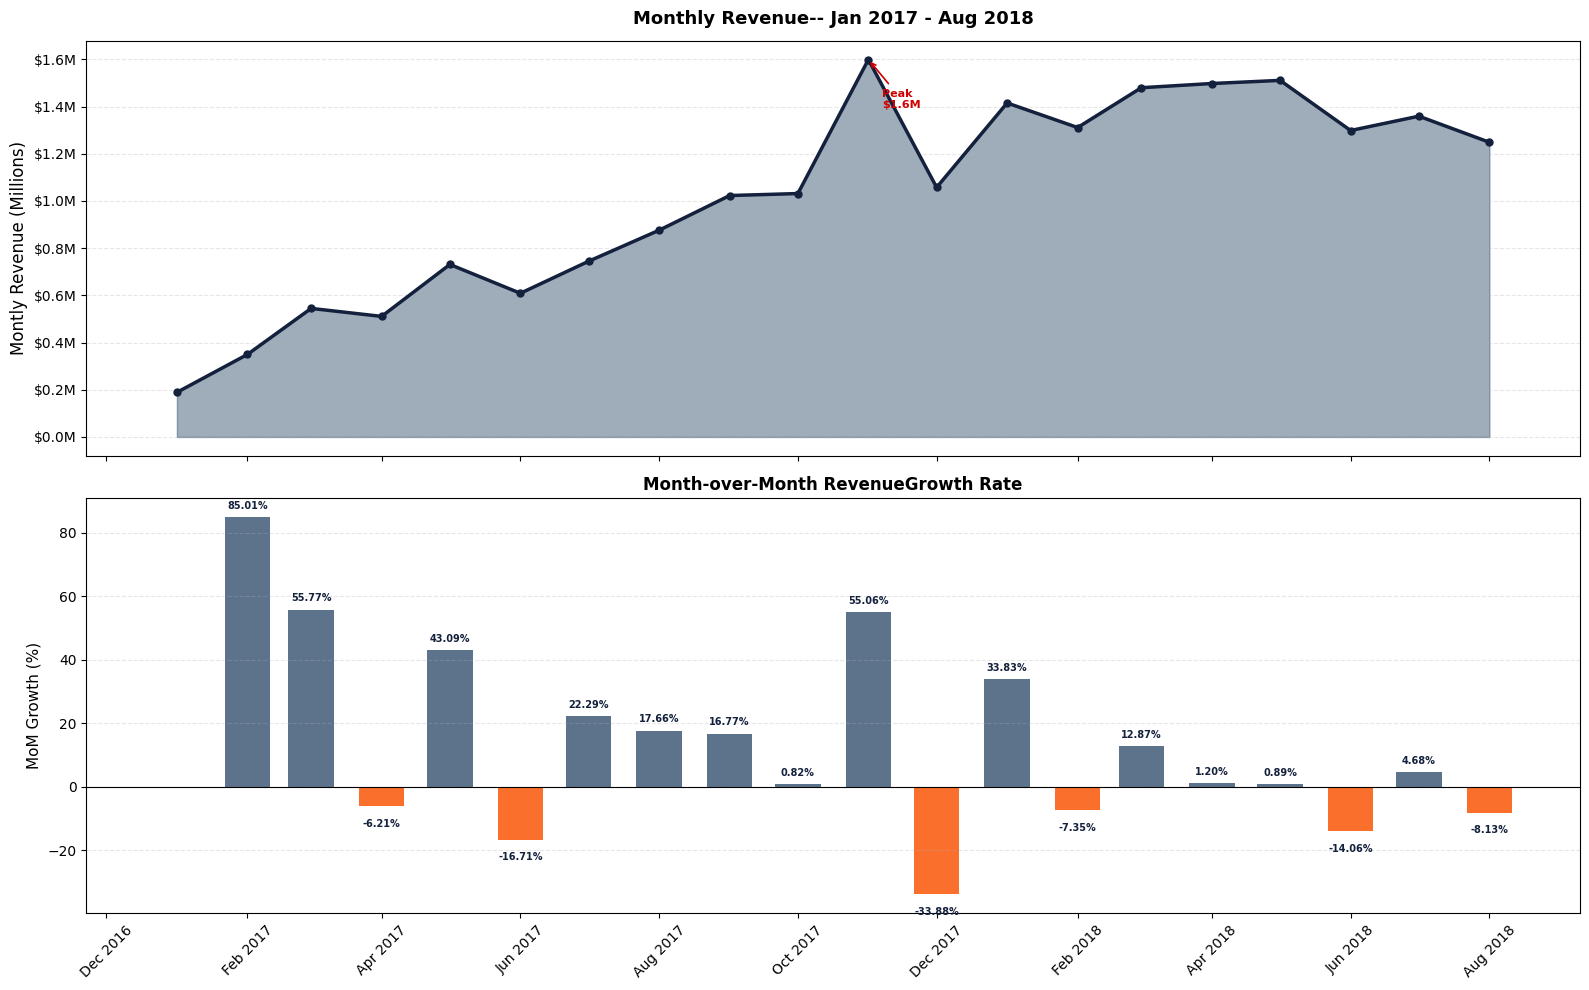

In [34]:
fig, (ax1 , ax2) = plt.subplots(
    2,1,
    figsize=(16,10),
    sharex=True,
  
)

revenue_millions = monthly_revenue['payment_value'] / 1e6
monthly_revenue['order_month'] = pd.to_datetime(monthly_revenue['order_month'])
month_dt = monthly_revenue['order_month']

ax1.plot(
    month_dt, revenue_millions,
    color=COLOUR_PRIMARY, linewidth=2.5,
    marker='o', markersize=5, zorder=3
)

ax1.fill_between(month_dt, revenue_millions, alpha=0.5, color=COLOUR_ACCENT)

peak_ann = monthly_revenue['payment_value'].idxmax()
peak_x = month_dt[peak_ann]
peak_y = revenue_millions[peak_ann]

ax1.annotate(
    f"Peak\n${peak_y:.1f}M",
    xy=(peak_x,peak_y),
    xytext=(10,-35),
    textcoords='offset points',
    fontsize=8, color=COLOUR_EMPHASIS, fontweight='semibold',
    arrowprops=dict(arrowstyle='->' , color=COLOUR_EMPHASIS, lw=1.2)
)

ax1.set_ylabel('Montly Revenue (Millions)', fontsize=12)
ax1.set_title(
    'Monthly Revenue-- '
    'Jan 2017 - Aug 2018',
    fontsize=13, fontweight='bold', pad=12
)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:.1f}M') 
)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

growth_data = monthly_revenue['mom_growth_pct'].fillna(0)
bar_colors = [
    COLOUR_ACCENT if x>= 0 else COLOUR_HIGHLIGHT for x in growth_data
]

ax2.bar(month_dt, growth_data, color=bar_colors, width=20 , alpha=0.85)
ax2.axhline(y=0 ,color='black', linewidth=0.8)

for x , y in zip(month_dt, growth_data):
    if y != 0 : ax2.text (
        x,y + (2 if y >= 0 else -4 ),
        f'{y:.2f}%',
        ha='center', va='bottom' if y >= 0 else'top',
        fontsize=7, color=COLOUR_PRIMARY, fontweight='semibold',
    )
        
ax2.set_ylabel('MoM Growth (%)', fontsize=11)
ax2.set_title('Month-over-Month RevenueGrowth Rate', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [55]:
##Checking the stats

master['order_year'] = master['order_purchase_timestamp'].dt.year

yearly_revenue = (
    master
    .groupby('order_year')['payment_value']
    .sum()
    .reset_index()
)
yearly_revenue = yearly_revenue[yearly_revenue['order_year'] != 2016]
yearly_revenue['yoy_growth_pct'] = (
    yearly_revenue['payment_value'].pct_change() * 100
)


print('Year over Year Revenue:')
print('='*50)

for _,row in yearly_revenue.iterrows():
    growth_str = (
        f"     (+ {row['yoy_growth_pct']:.1f}% YoY)"
        if not pd.isna(row['yoy_growth_pct'])
        else ''
    )
    print(f"   {int(row['order_year'])} : "
          f"${row['payment_value']:>12,.2f}{growth_str}")

Year over Year Revenue:
   2017 : $9,266,612.28
   2018 : $11,127,586.12     (+ 20.1% YoY)


In [53]:
master['month_of_year'] = master['order_purchase_timestamp'].dt.month
monthly_avg = (
    master
    .groupby('month_of_year')['payment_value']
    .sum()
    .reset_index()
)

months = {
    1:'Jan' , 2: 'Feb', 3: 'Mar' , 4: 'Apr' , 5:'May' , 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec', 
}

monthly_avg['month'] = monthly_avg['month_of_year'].map(months)

print(f"\nRevenue by Month of year")
print('-'*45)
for _, row in monthly_avg.iterrows():
    bar = '✔' * int(row['payment_value'] / monthly_avg['payment_value'].max() * 30)
                    
    print(f"   {row['month']}: {bar}   ${row['payment_value']:>12,.0f}")


Revenue by Month of year
---------------------------------------------
   Jan: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   1,604,364
   Feb: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   1,660,963
   Mar: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   2,024,784
   Apr: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   2,008,735
   May: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   2,242,130
   Jun: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   1,907,577
   Jul: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   2,104,021
   Aug: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   2,124,967
   Sep: ✔✔✔✔✔✔✔✔✔✔✔✔✔   $   1,027,924
   Oct: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   1,108,215
   Nov: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   1,599,444
   Dec: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   1,057,602


## Analysis 1 — Revenue Trend: Observations & Findings
 
---
 
### Data Coverage Note
 
The Olist dataset spans September 2016 to October 2018 but only
contains complete monthly data across two time windows:
 
- **2016 (Sep–Dec):** Platform launch period. Excluded from trend
  analysis — partial months with as few as 1 day of orders produce
  astronomically distorted growth rates (e.g. +963,000% MoM).
- **2017 (Jan–Dec):** Full year, 12 complete months. ✓
- **2018 (Jan–Aug):** 8 complete months before dataset truncation. ✓
- **2018 (Sep–Oct):** Excluded — dataset cut off mid-month.
 
**All revenue trend analysis uses 20 complete months (Jan 2017 – Aug 2018).**
 
---
 
### Finding 1 — Strong Year-over-Year Growth
 
Revenue grew from **R$9.27M in 2017 to R$11.13M in 2018 (+20.1% YoY)**.

 Note: Compared to 12 months for 2017, the 2018 statistic only includes 8 months (January through August). 2018 was tracking much higher on an annual basis; projecting the 8-month average forward yields a projected full-year 2018 revenue of around**R$16.7M** indicates actual YoY growth that is closer to **+80%**.

 *Implication: During the dataset period, the company was experiencing robust growth. Inventory planning and revenue-based goals should take the ongoing rising trend into consideration.*
---
 
### Finding 2 — Black Friday Spike (November 2017)
 
November 2017 recorded the **peak single-month revenue of R$1.6M**,
representing a **+55% spike** above October 2017.
 
This is followed by a sharp -34% correction in December 2017 —
consistent with post-promotional demand exhaustion seen across
most e-commerce markets globally.

*Important disclaimer: The dataset only includes one instance of November and December (2017 only; 2018 equivalents were reduced). Although this result is directionally correct, it cannot be verified as a consistent yearly pattern based only on this dataset.*
 
*Implication: Inventory, logistics capacity, and seller support,should be scaled up in October each year in preparation for the November demand surge.*
 
---
 
### Finding 3 — Mid-Year Strength, Not Classic Seasonality
 
Aggregating revenue by calendar month across both years reveals
**May, August, and July as the three highest-revenue months**
(R$2.24M, R$2.12M, and R$2.10M respectively).
 
In markets in the Northern Hemisphere, this may seem contradictory.
The busiest month for retail is usually December. Brazil's summer months are December through February, which could help to explain some patterns of consumer spending.
 
**Disclaimer on this finding:** September and October appear lower
(R$1.03M and R$1.11M) because they only contain 2017 data —
their 2018 equivalents were excluded due to truncation. Their
bars are not directly comparable to Jan–Aug which contain two
years of data summed.
 
*Implication: Month-of-year revenue patterns for this Brazilian marketplace differ from Northern Hemisphere norms. Marketing and promotional planning should be calibrated to local patterns.*
 
---
 
### Finding 4 — Growth Maturation Through 2018
 
Early 2017 showed explosive MoM growth rates (+85% in Feb 2017,
+55% in Mar 2017) consistent with a platform in early hypergrowth.
 
By 2018 MoM growth had moderated to single digits in most months
(+0.9% in May 2018, +1.2% in Apr 2018), suggesting the platform
was maturing and stabilising at a higher revenue base rather than
continuing to grow exponentially.
 
*Implication: The business appears to be transitioning from acquisition-driven growth to retention-driven growth — making customer lifetime value and churn prediction increasingly important analytical priorities (addressed in Notebooks 02 and 03).*
 
---
 
### Summary 

| Analysis period | Jan 2017 – Aug 2018 (20 months) |
| 2017 total revenue | R$9,266,612 |
| 2018 total revenue (8 months) | R$11,127,586 |
| YoY growth (comparable periods) | +20.1% |
| Peak month | November 2017 — R$1,599,444 |
| Highest MoM growth | February 2017 — +85.0% |
| Largest MoM decline | December 2017 — -33.9% |
| Strongest calendar month | May — R$2,242,130 (2 years summed) |
 
---
*Feeds into: Analysis 3 (Delivery Performance) where we test
whether delivery delays are statistically associated with
review score — a key driver of repeat purchase and revenue.*
"""